In [82]:
import os
import torch
import numpy as np
os.environ["KERAS_BACKEND"] = "torch"

In [83]:
if torch.backends.mps.is_available():
    print("Apple's MPS backend (used by PyTorch on M1/M2 Macs) does not support float64 (double precision).")
    mps_enabled = True
    torch.set_default_dtype(torch.float32)
    print("set default to float32")

Apple's MPS backend (used by PyTorch on M1/M2 Macs) does not support float64 (double precision).
set default to float32


In [84]:
import keras
from utils.project_utils import update_json, standard_plot, plot_confusion_matrix
from executors.executors import build_model_single_hidden, build_model_two_hidden
from utils.data_loader import get_monk_data

## Part 1: Monk

In [ ]:
# --- MONK ---
# 1. Load Data
monk_results = {}
batch_size = 64 # Explicitly define batch_size for Keras notebook

experiments = [
    {'id': 1, 'reg': False, 'name': 'Monk-1'},
    {'id': 2, 'reg': False, 'name': 'Monk-2'},
    {'id': 3, 'reg': False, 'name': 'Monk-3'},
    {'id': 3, 'reg': True, 'name': 'Monk-3-Reg'}
]

for exp in experiments:
    monk_id = exp['id']
    is_reg = exp['reg']
    task_name = exp['name']
    
    print(f"\n--- Analyzing {task_name} ---")
    train_loader, test_loader, input_size, output_size = get_monk_data(monk_id, batch_size)
    
    # Keras Model Builder
    def build_monk_model(hidden_units, learning_rate, momentum, l2_reg=0.0):
        reg = keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
        model = keras.Sequential([
            keras.layers.Dense(hidden_units, activation='relu', input_shape=(input_size,), kernel_regularizer=reg),
            keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=reg)
        ])
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        return model

    # Grid Search
    learning_rates = [0.01, 0.1]
    momentums = [0.9]
    hidden_units_list = [4, 8]
    l2_regs = [0.0] if not is_reg else [0.1, 0.5]
    epochs_list = [100]
    
    best_acc = 0.0
    best_config = {}
    best_history = {}
    
    for lr in learning_rates:
        for mom in momentums:
            for hu in hidden_units_list:
                for l2 in l2_regs:
                    for epochs in epochs_list:
                        # Clear session to avoid clutter
                        keras.backend.clear_session()
                        
                        model = build_monk_model(hu, lr, mom, l2)
                        
                        # Convert loaders to numpy for Keras
                        X_train = train_loader.dataset.tensors[0].numpy()
                        y_train = train_loader.dataset.tensors[1].numpy()
                        X_test = test_loader.dataset.tensors[0].numpy()
                        y_test = test_loader.dataset.tensors[1].numpy()
                        
                        history = model.fit(
                            X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(X_test, y_test),
                            verbose=0
                        )
                        
                        val_acc = history.history['val_accuracy'][-1]
                        if val_acc > best_acc:
                            best_acc = val_acc
                            best_config = {'lr': lr, 'momentum': mom, 'hidden_units': hu, 'l2_reg': l2, 'epochs': epochs}
                            best_history = history.history
    
    print(f"Best Config for {task_name}: {best_config}, Acc: {best_acc}")
    
    # Save Results
    standard_plot(best_history, f"{task_name} Best Model", f"{task_name.lower().replace('-', '_')}_keras.png")
    update_json(task_name, "Keras", {"test_accuracy": best_acc, "config": best_config})

    
    # Re-build best model to plot Confusion Matrix
    print(f"Generating Confusion Matrix for {task_name}...")
    keras.backend.clear_session()
    best_lr = best_config['lr']
    best_mom = best_config['momentum']
    best_hu = best_config['hidden_units']
    best_l2 = best_config['l2_reg']
    best_epochs = best_config['epochs']
    
    model = build_monk_model(best_hu, best_lr, best_mom, best_l2)
    
    X_train = train_loader.dataset.tensors[0].numpy()
    y_train = train_loader.dataset.tensors[1].numpy()
    X_test = test_loader.dataset.tensors[0].numpy()
    y_test = test_loader.dataset.tensors[1].numpy()
    
    model.fit(X_train, y_train, epochs=best_epochs, batch_size=batch_size, verbose=0)
    
    y_pred = model.predict(X_test, verbose=0)
    plot_confusion_matrix(y_test, y_pred, f"{task_name} Best Model", f"{task_name.lower().replace('-', '_')}_keras_cm.png")


# Part 2: ML-CUP

In [85]:
if keras.backend.backend() != "torch":
    print(f"warning: keras backend is set to {keras.backend.backend()}, restart jupyter kernel!!!!")
    raise RuntimeError()

In [86]:
keras.backend.backend()

'torch'

In [87]:
import json

global config
with open('./config/keras_nn.json') as keras_nn_config:
    config = json.load(keras_nn_config)
    print("config loaded")

config loaded


In [88]:
# Root-level fields
batch_size = config["batchSize"]
scaler_enabled = config["scaler"]["enabled"]
scaler_type = config["scaler"]["type"]
input_size = config["inputSize"]
output_size = config["outputSize"]
seed = config["seed"]

In [89]:
keras.utils.set_random_seed(seed)

In [90]:
%load_ext tensorboard
# now available at http://localhost:6006/?

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [91]:
# Dataset initialization
from utils.data_loader import get_ml_cup_data, split_dataloader, cv_fold_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

def _scaler():
    if not scaler_enabled:
        return None

    if scaler_type == "Standard":
        return StandardScaler()
    elif scaler_type == "MinMax":
        return MinMaxScaler()
    elif scaler_type == "Robust":
        return RobustScaler()
    elif scaler_type == "MaxAbsScaler":
        return MaxAbsScaler()
    else:
        return None

# We use validation_ratio=0.0 and scale_target=False to match the behavior 
# of the old data_loader_2 (which only did a Train/Test split and didn't scale targets).
# We unpack the result to get train_loader and internal_test_loader.
train_loader, _, test_loader, _, _, _= get_ml_cup_data(
    batch_size=batch_size,
    validation_ratio=0.0,
    test_ratio=0.20,  # Standard ratio from old loader
    scaler=_scaler(),
    scale_target=False # Old loader did not scale targets automatically
)

# Note: 'mps_enabled' logic is handled internally: data_loader.py automatically 
# uses float32 tensors (compatible with MPS) and checks for GPU memory pinning.

Parsing ML-CUP data (TR only)...
Data Split: Train=400, Val=0, Internal Test=100
Applying scaling StandardScaler to Inputs...


In [92]:
train_loader.dataset.X.shape, train_loader.dataset.y.shape

(torch.Size([400, 12]), torch.Size([400, 4]))

In [93]:
test_loader.dataset.X.shape, test_loader.dataset.y.shape

(torch.Size([100, 12]), torch.Size([100, 4]))

In [94]:
test_loader.dataset.y.shape[1]

4

In [95]:
import numpy as np

y_mean = train_loader.dataset.y.mean(axis=0)        # (4,)

y_pred_baseline = np.tile(y_mean, (len(train_loader.dataset.y), 1))

mee_errors = np.linalg.norm(train_loader.dataset.y - y_pred_baseline, axis=1)
mse_errors = np.square(train_loader.dataset.y - y_pred_baseline)

mee_baseline = mee_errors.mean()
mse_baseline = mse_errors.mean()

print("Baseline MEE:", mee_baseline)
print("Baseline MSE:", mse_baseline)

Baseline MEE: 35.881134
Baseline MSE: tensor(369.0105)


/var/folders/q_/svzf5dgd69q5h8h686ps7qxw0000gn/T/ipykernel_23520/559558886.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mee_errors = np.linalg.norm(train_loader.dataset.y - y_pred_baseline, axis=1)
/var/folders/q_/svzf5dgd69q5h8h686ps7qxw0000gn/T/ipykernel_23520/559558886.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mse_errors = np.square(train_loader.dataset.y - y_pred_baseline)


In [96]:
from losses import MeanEuclidianError

mee = MeanEuclidianError(name="mee", dtype=torch.float32)

In [97]:
train_dataset = train_loader.dataset
test_dataset = test_loader.dataset

## Grid Search vs Randomized vs Optuna Comparison\n
Before running the full randomized search, we perform a direct comparison between **Grid Search**, **Randomized search** and **Optuna**.\n
We use a expanded budget of **288 trials** for all methods.\n
\n
- **Grid Search**: Exhaustive search over the discrete grid.\n
- **Randomized & Optuna**: Continuous search within the ranges defined by the grid boundaries.\n
\n
**Search Space:**\n
- **Hidden Units**: Fixed at 16\n
- **LR**: Grid [1e-4 .. 5e-2] | Continuous Log-Uniform [1e-4, 5e-2]\n
- **Momentum**: Grid [0.5 .. 0.9] | Continuous Uniform [0.5, 0.9]\n
- **Weight Decay**: Grid [0.0 .. 1e-1] | Continuous Log-Uniform [1e-5, 1e-1]\n
- **Activation**: ['relu', 'tanh']\n

--- Starting Grid Search vs Optuna vs Random Search Comparison (288 Trials each) ---
Running Grid Search (Discrete Grid)...
Grid Trial 20/288: {'lr': 0.0001, 'momentum': 0.7, 'weight_decay': 0.001, 'activation': 'tanh'} => MEE: 33.3497
Grid Trial 40/288: {'lr': 0.0001, 'momentum': 0.9, 'weight_decay': 1e-05, 'activation': 'tanh'} => MEE: 29.1885
Grid Trial 60/288: {'lr': 0.0005, 'momentum': 0.5, 'weight_decay': 0.1, 'activation': 'tanh'} => MEE: 29.1833
Grid Trial 80/288: {'lr': 0.0005, 'momentum': 0.8, 'weight_decay': 0.001, 'activation': 'tanh'} => MEE: 28.1255
Grid Trial 100/288: {'lr': 0.001, 'momentum': 0.5, 'weight_decay': 1e-05, 'activation': 'tanh'} => MEE: 28.2392
Grid Trial 120/288: {'lr': 0.001, 'momentum': 0.7, 'weight_decay': 0.1, 'activation': 'tanh'} => MEE: 27.8980
Grid Trial 140/288: {'lr': 0.001, 'momentum': 0.9, 'weight_decay': 0.001, 'activation': 'tanh'} => MEE: 27.6029
Grid Trial 160/288: {'lr': 0.005, 'momentum': 0.7, 'weight_decay': 1e-05, 'activation': 'tanh'} 

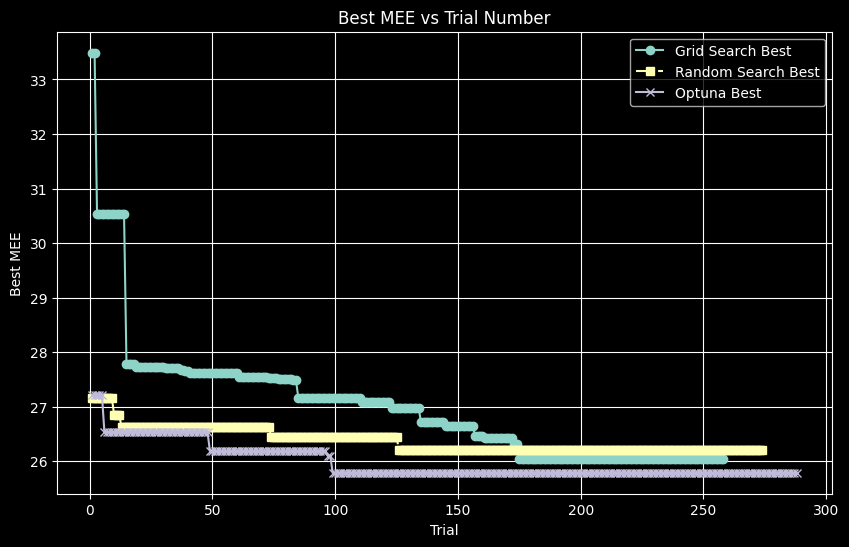

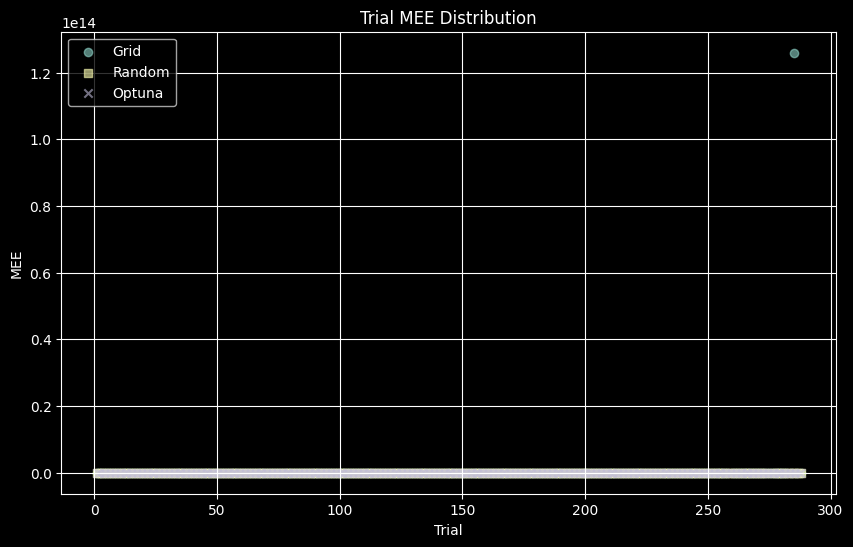

In [98]:
# --- GRID SEARCH vs OPTUNA COMPARISON ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import keras
from keras import layers
import optuna
import time
import random

# 0. Plot Styling (White Background)
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['grid.color'] = '#e0e0e0'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# 1. Setup Data
print("--- Starting Grid Search vs Optuna vs Random Search Comparison (288 Trials each) ---")
if 'train_loader' not in globals():
    print("Error: train_loader not found. Run previous cells first.")
else:
    # Extract Numpy Data
    # Ensure we copy to CPU numpy arrays to avoid any device confusion during slicing
    X_train_cmp = train_loader.dataset.X.cpu().numpy()
    y_train_cmp = train_loader.dataset.y.cpu().numpy()
    
    # Manual Split for Comparison (80/20 of the Train set)
    # This mimics the PyTorch validation split
    val_split_idx = int(0.8 * len(X_train_cmp))
    X_t_cmp = X_train_cmp[:val_split_idx]
    y_t_cmp = y_train_cmp[:val_split_idx]
    X_v_cmp = X_train_cmp[val_split_idx:]
    y_v_cmp = y_train_cmp[val_split_idx:]
    
    input_dim = X_train_cmp.shape[1]
    output_dim = y_train_cmp.shape[1]

    # Define Search Space
    grid_space = {
        'lr': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2],
        'momentum': [0.5, 0.7, 0.8, 0.9],
        'weight_decay': [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        'activation': ['relu', 'tanh']
    }
    fixed_hidden_units = 16
    N_EPOCHS_COMPARE = 20

    def train_and_eval(params):
        # Optimized Keras implementation for Speed
        keras.backend.clear_session() 
        
        reg = keras.regularizers.l2(params['weight_decay']) if params['weight_decay'] > 0 else None
        
        # functional API is slightly faster to build than Sequential sometimes
        inputs = keras.Input(shape=(input_dim,))
        x = layers.Dense(fixed_hidden_units, activation=params['activation'], kernel_regularizer=reg)(inputs)
        x = layers.Dense(fixed_hidden_units, activation=params['activation'], kernel_regularizer=reg)(x)
        outputs = layers.Dense(output_dim)(x)
        model = keras.Model(inputs=inputs, outputs=outputs)
        
        optimizer = keras.optimizers.SGD(learning_rate=params['lr'], momentum=params['momentum'])
        
        # Compile with run_eagerly=False (default) but ensure steps are minimized
        model.compile(optimizer=optimizer, loss='mse')
        
        # Run training - Validation removed for speed parity with PyTorch
        model.fit(
            X_t_cmp, y_t_cmp,
            epochs=N_EPOCHS_COMPARE,
            verbose=0,
            batch_size=32,
            shuffle=True
        )
        
        # Evaluate MEE manually
        # Use batch processing for prediction to ensure speed
        y_pred = model.predict(X_v_cmp, verbose=0)
        
        # Ensure shapes match
        if y_pred.shape != y_v_cmp.shape:
            print(f"Shape mismatch! {y_pred.shape} vs {y_v_cmp.shape}")
            y_pred = y_pred.reshape(y_v_cmp.shape)
            
        diff = y_pred - y_v_cmp
        # Euclidean norm per row, then mean
        mee = np.mean(np.linalg.norm(diff, axis=1))
        return mee

    # --- 2. GRID SEARCH ---
    print("Running Grid Search (Discrete)...")
    grid_results = {'trial': [], 'value': [], 'lr': [], 'momentum': [], 'weight_decay': [], 'activation': []}
    trial_idx = 0
    start_time = time.time()

    for lr in grid_space['lr']:
        for mom in grid_space['momentum']:
            for wd in grid_space['weight_decay']:
                for act in grid_space['activation']:
                    trial_idx += 1
                    params = {'lr': lr, 'momentum': mom, 'weight_decay': wd, 'activation': act}
                    val_mee = train_and_eval(params)
                    
                    grid_results['trial'].append(trial_idx)
                    grid_results['value'].append(val_mee)
                    grid_results['lr'].append(lr)
                    grid_results['momentum'].append(mom)
                    grid_results['weight_decay'].append(wd)
                    grid_results['activation'].append(act)
                    if trial_idx % 20 == 0:
                        print(f"Grid Trial {trial_idx}/288: MEE: {val_mee:.4f}")
    grid_time = time.time() - start_time

    # --- 2.5. RANDOM SEARCH ---
    print("Running Random Search (Continuous)...")
    random_results = {'trial': [], 'value': [], 'lr': [], 'momentum': [], 'weight_decay': [], 'activation': []}
    random.seed(42)
    start_time = time.time()
    TOTAL_TRIALS = 288

    for i in range(TOTAL_TRIALS):
        r_lr = 10 ** random.uniform(np.log10(1e-4), np.log10(5e-2))
        r_mom = random.uniform(0.5, 0.9)
        r_wd = 10 ** random.uniform(np.log10(1e-5), np.log10(1e-1))
        r_act = random.choice(grid_space['activation'])
        
        params = {'lr': r_lr, 'momentum': r_mom, 'weight_decay': r_wd, 'activation': r_act}
        val_mee = train_and_eval(params)
        
        random_results['trial'].append(i + 1)
        random_results['value'].append(val_mee)
        random_results['lr'].append(r_lr)
        random_results['momentum'].append(r_mom)
        random_results['weight_decay'].append(r_wd)
        random_results['activation'].append(r_act)
        if (i+1) % 20 == 0:
            print(f"Random Trial {i+1}/{TOTAL_TRIALS}: MEE: {val_mee:.4f}")
    random_time = time.time() - start_time

    # --- 3. OPTUNA SEARCH ---
    print("Running Optuna Search...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    def objective(trial):
        params = {
            'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
            'momentum': trial.suggest_float('momentum', 0.5, 0.9),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True),
            'activation': trial.suggest_categorical('activation', grid_space['activation'])
        }
        return train_and_eval(params)

    start_time = time.time()
    study_cmp = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study_cmp.optimize(objective, n_trials=TOTAL_TRIALS)
    optuna_time = time.time() - start_time

    optuna_results = {'trial': [], 'value': [], 'lr': [], 'momentum': [], 'weight_decay': [], 'activation': []}
    for t in study_cmp.trials:
        optuna_results['trial'].append(t.number + 1)
        optuna_results['value'].append(t.value)
        optuna_results['lr'].append(t.params['lr'])
        optuna_results['momentum'].append(t.params['momentum'])
        optuna_results['weight_decay'].append(t.params['weight_decay'])
        optuna_results['activation'].append(t.params['activation'])

    # --- 4. VISUALIZATION ---
    print(f"Comparison Complete.")
    print(f"Grid Time: {grid_time:.2f}s")
    print(f"Random Time: {random_time:.2f}s")
    print(f"Optuna Time: {optuna_time:.2f}s")

    # Best Value Plot
    grid_best = np.minimum.accumulate(grid_results['value'])
    random_best = np.minimum.accumulate(random_results['value'])
    opt_best = np.minimum.accumulate(optuna_results['value'])

    plt.figure(figsize=(10, 6))
    plt.plot(grid_results['trial'], grid_best, label='Grid Search Best', marker='o', markevery=20)
    plt.plot(random_results['trial'], random_best, label='Random Search Best', marker='s', linestyle='-.', markevery=20)
    plt.plot(optuna_results['trial'], opt_best, label='Optuna Best', marker='x', markevery=20)
    plt.title('Best MEE vs Trial Number')
    plt.xlabel('Trial')
    plt.ylabel('Best MEE')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Scatter Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(grid_results['trial'], grid_results['value'], label='Grid', alpha=0.5, s=15)
    plt.scatter(random_results['trial'], random_results['value'], label='Random', alpha=0.5, marker='s', s=15)
    plt.scatter(optuna_results['trial'], optuna_results['value'], label='Optuna', alpha=0.5, marker='x', s=15)
    plt.title('Trial MEE Distribution')
    plt.xlabel('Trial')
    plt.ylabel('MEE')
    plt.legend()
    plt.grid(True)
    plt.show()


## Randomized Search

In [ ]:
from scipy.stats import loguniform

param_distributions = {
    "reg__model__learning_rate": loguniform(1e-3, 1e-2),
    "reg__model__lambda_1": loguniform(3e-3, 1e-1),
    "reg__model__lambda_2": loguniform(3e-3, 1e-1),
    "reg__model__activation_1": ["relu", "gelu", "leaky_relu"],
    "reg__model__activation_2": ["relu", "gelu", "leaky_relu"],
    "reg__model__dropout_1": loguniform(0.2, 0.5),
    "reg__model__dropout_2": loguniform(0.2, 0.5),
    "reg__model__pca_input_size": [1, 2],
    "reg__pca__n_components": [1, 2],
    "reg__model__seed": [seed],
    "reg__model__output_size": [train_loader.dataset.y.shape[1]],
}

In [ ]:
from executors import RandomizedSearchRegressionExecutor

# using default param_distribution
rs_regression_executor = RandomizedSearchRegressionExecutor(
    train_loader=train_loader,
    units=[(2,2)],
    n_iter=1,
    epochs=1,
    use_PCA=True,
    loss="mean_squared_error",
    baseline=mse_baseline,
    scoring="neg_mean_squared_error",
    seed=seed,
    save_path="keras/models/rs/test",
    verbose=0,
    n_jobs=4
)

In [ ]:
rs_regression_executor.execute()

## Optuna

In [ ]:
import optuna
from executors import OptunaRegressorExecutor

optuna_executor = OptunaRegressorExecutor(
    train_loader=train_loader,
    units=[(12,12)],
    use_pca=True,
    pca_input_size=2,
    n_trials=100,
    epochs=1000,
    seed=seed,
    batch_size=80,
    n_splits=5,
    sampler=optuna.samplers.TPESampler(seed=seed, constant_liar=True, multivariate=True),
    optuna_base_path="keras/models/optuna/regression27-12",
    verbose=0,
    baseline=mse_baseline,
    n_jobs=4
)

In [ ]:
optuna_executor.execute()

In [ ]:
import utils.optuna_utils as uoptuna

study = uoptuna.import_csv("keras/models/optuna/regression27-12/12x12/optuna_results.csv")

In [ ]:
from optuna.visualization import \
    plot_optimization_history, plot_param_importances, plot_parallel_coordinate, plot_contour

In [ ]:
plot_optimization_history(study)

In [ ]:
study.best_params

In [ ]:
plot_param_importances(study)

In [ ]:
plot_parallel_coordinate(study)

In [ ]:
plot_contour(study, params=['dropout_2', 'learning_rate'])

In [ ]:
from utils.plot import plot_optuna_vs_random

plot_optuna_vs_random(
    optuna_csv_path="keras/models/optuna/regression27-12/12x12/optuna_results.csv",
    rs_csv_path="keras/models/rs/regression27-12/12x12/cv_results_df.csv"
                      )

In [ ]:
# --- FINAL CUP EVALUATION ---
print("\n--- Final CUP Evaluation with Best Params ---")
# Assuming 'study' is available from previous cells
best_params = study.best_params
print("Best Params:", best_params)

# Extract params (assuming 12x12 architecture as per notebook default)
unit1 = 12
unit2 = 12

lr = best_params['learning_rate']
l1 = best_params['lambda_1']
act1 = best_params['activation_1']
drop1 = best_params['dropout_1']

l2 = best_params.get('lambda_2', 0.0)
act2 = best_params.get('activation_2', 'relu')
drop2 = best_params.get('dropout_2', 0.0)

meta = {"n_features_in_": input_size, "n_outputs_": output_size}

# Build Model
model = build_model_two_hidden(
    meta, unit1, unit2, seed, lr, drop1, drop2, l1, l2, act1, act2
)

# Train on Full Train Data (Train+Val)
# train_loader in notebook is already Train+Val (validation_ratio=0.0)
X_train = train_loader.dataset.X.numpy()
y_train = train_loader.dataset.y.numpy()
X_test = test_loader.dataset.X.numpy()
y_test = test_loader.dataset.y.numpy()

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(monitor='loss', patience=50, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    epochs=1000, # Train longer for final
    batch_size=batch_size,
    verbose=0,
    callbacks=callbacks
)

# Evaluate
# MEE is in metrics (index 1 usually, index 0 is loss)
results = model.evaluate(X_test, y_test, verbose=0)
loss = results[0]
mee_score = results[1]
print(f"Final Internal Test MEE: {mee_score}")

# Save Results
update_json("CUP", "Keras", {"internal_test_MEE": mee_score})
standard_plot(history.history, "CUP Keras Training", "cup_keras.png")

# Save the Best Model
import os
os.makedirs("models", exist_ok=True)
model_save_path = "models/best_keras_mlcup.keras"
model.save(model_save_path)
print(f"Best Keras model saved to {model_save_path}")
